# CinCECGTorso: 4-class clustering of long ECG signals

UCR CinCECGTorso, 1420 single-lead ECG records of length
1639 from the Computers in Cardiology 2007 challenge, 4 balanced
classes (~355 records each) corresponding to recording-mode
categories.

Classes differ along two essentially
independent axes: morphology (waveform shape after z-normalisation)
and amplitude (peak-to-peak swing). 

`filt_shape` is L2 between z-normalised pairs (amplitude removed)

`filt_amp` is the peak-to-peak difference. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                              f1_score, precision_score, recall_score)
from scipy.spatial.distance import cdist
from tslearn.datasets import UCR_UEA_datasets
import hdbscan

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges
from mpc.experiment_utils import align_hungarian

## Data

full set: N=1420 L=1639
subsample: N=200 L=1639, class counts: [50 50 50 50]


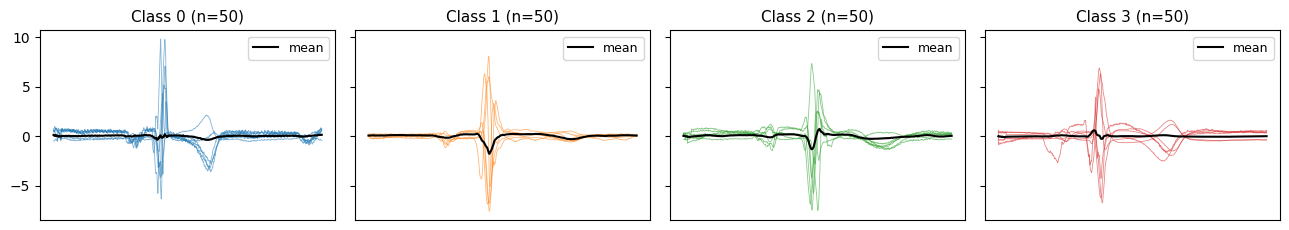

In [2]:
X_tr, y_tr, X_te, y_te = UCR_UEA_datasets().load_dataset('CinCECGTorso')
X_full = np.vstack([X_tr.squeeze(-1), X_te.squeeze(-1)])
y_full = np.concatenate([y_tr, y_te]).astype(int) - 1
print(f"full set: N={len(X_full)} L={X_full.shape[1]}")

K_TRUE = 4
PER_CLASS = 50
rng = np.random.default_rng(42)
sel = []
for c in range(K_TRUE):
    idx_c = np.where(y_full == c)[0]
    sel.extend(rng.choice(idx_c, PER_CLASS, replace=False))
sel = np.array(sel); rng.shuffle(sel)
X = X_full[sel]; y_true = y_full[sel]
N, L = X.shape
print(f"subsample: N={N} L={L}, class counts: {np.bincount(y_true)}")

CLASS_COLORS = ["C0", "C1", "C2", "C3"]
fig, axes = plt.subplots(1, K_TRUE, figsize=(13, 2.4), sharey=True)
for ax, c in zip(axes, range(K_TRUE)):
    for i in np.where(y_true == c)[0][:6]:
        ax.plot(X[i], color=CLASS_COLORS[c], lw=0.6, alpha=0.55)
    ax.plot(X[y_true == c].mean(0), color="k", lw=1.5, label="mean")
    ax.set_title(f"Class {c} (n={(y_true == c).sum()})", fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Filtrations

Two axes on the full set of 200 records:

`filt_shape` -- L2 between z-normalized waveforms.

`filt_amp` -- |peak2peak_i - peak2peak_j|.

In [3]:
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)
amp = X.max(1) - X.min(1)

D_shape = cdist(Xz, Xz)
D_amp = np.abs(amp[:, None] - amp[None, :])

iu, ju = np.triu_indices(N, k=1)
edges = list(zip(iu.tolist(), ju.tolist()))
filt_shape = assemble_filtration(N, edges, D_shape[iu, ju])
filt_amp   = assemble_filtration(N, edges, D_amp[iu, ju])
print(f"N={N}, edges={len(edges)}")

N=200, edges=19900


## Clustering

Each method runs once on the full set. Metrics: ARI, NMI, and macro
precision/recall/F1 after Hungarian alignment to ground-truth labels.

Bifiltration on `filt_shape x filt_amp`, simplify mode, `slope = 1`,
`K = 4`, `min_size = N / 10`.

KMeans, Ward, HDBSCAN run on the z-normalized waveform `Xz`
(L = 1639) so that they see the same shape information as `filt_shape`.

For F1/P/R cluster IDs are remapped to ground-truth class IDs via
Hungarian assignment (overlap-maximizing).

In [ ]:
K = K_TRUE  # = 4
min_size = N // 10  # for N=200 gives 20

bif_res = run_bifiltration_edges(N, filt_shape, filt_amp,
                                 method="simplify", n_clusters=K,
                                 slope=1.0, min_size=min_size)
labels_bif = bif_res.labels_combined

labels_km   = KMeans(n_clusters=K, n_init=50, max_iter=500,
                     random_state=42).fit_predict(Xz)
labels_ward = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xz)
labels_hdb  = hdbscan.HDBSCAN(min_cluster_size=min_size).fit_predict(Xz)

methods = {
    f"Bifiltration (slope=1, m={min_size})": labels_bif,
    "KMeans on Xz": labels_km,
    "Ward on Xz":   labels_ward,
    f"HDBSCAN on Xz (mcs={min_size})": labels_hdb,
}

rows = []
for name, labels in methods.items():
    labels = np.asarray(labels)
    a, _ = align_hungarian(labels, y_true)
    gt = (y_true + 1)
    rows.append({
        "method": name,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels),
        "P": precision_score(gt, a, average="macro", zero_division=0),
        "R": recall_score(gt, a, average="macro", zero_division=0),
        "F1": f1_score(gt, a, average="macro", zero_division=0),
    })
df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True).round(3)
df

,method,ARI,NMI,P,R,F1
0,"Bifiltration (slope=1, m=20)",0.643,0.725,0.866,0.835,0.830
1,Ward on Xz,0.208,0.327,0.556,0.485,0.497
2,KMeans on Xz,0.193,0.298,0.463,0.460,0.459
3,HDBSCAN on Xz (mcs=20),0.164,0.307,0.392,0.475,0.417


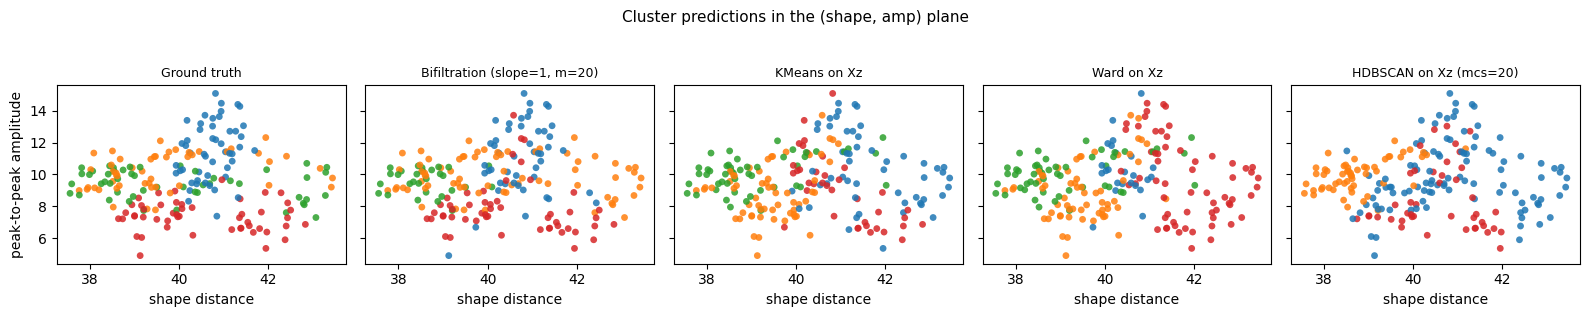

In [ ]:
PRED_COLORS = ["C0", "C1", "C2", "C3"]

shape_dist_vis = np.linalg.norm(Xz - Xz.mean(0), axis=1)

methods_to_show = [("Ground truth", y_true)] + [(name, labels) for name, labels in methods.items()]

fig, axes = plt.subplots(1, len(methods_to_show), figsize=(16, 3.0),
                         sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, methods_to_show):
    labels = np.asarray(labels)
    if name == "Ground truth":
        color_idx = labels
    else:
        a, _ = align_hungarian(labels, y_true)
        color_idx = (a - 1) % K_TRUE
    colors = [PRED_COLORS[c] for c in color_idx]
    ax.scatter(shape_dist_vis, amp, c=colors, s=24, alpha=0.85, edgecolors="none")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("shape distance")
axes[0].set_ylabel("peak-to-peak amplitude")
fig.suptitle("Cluster predictions in the (shape, amp) plane", y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

## Series grouped by ground-truth class

Each row is one method or ground truth. Columns are the 4 ground-truth
classes. Lines coloured by predicted cluster after Hungarian alignment.
A perfect method paints each panel one colour.

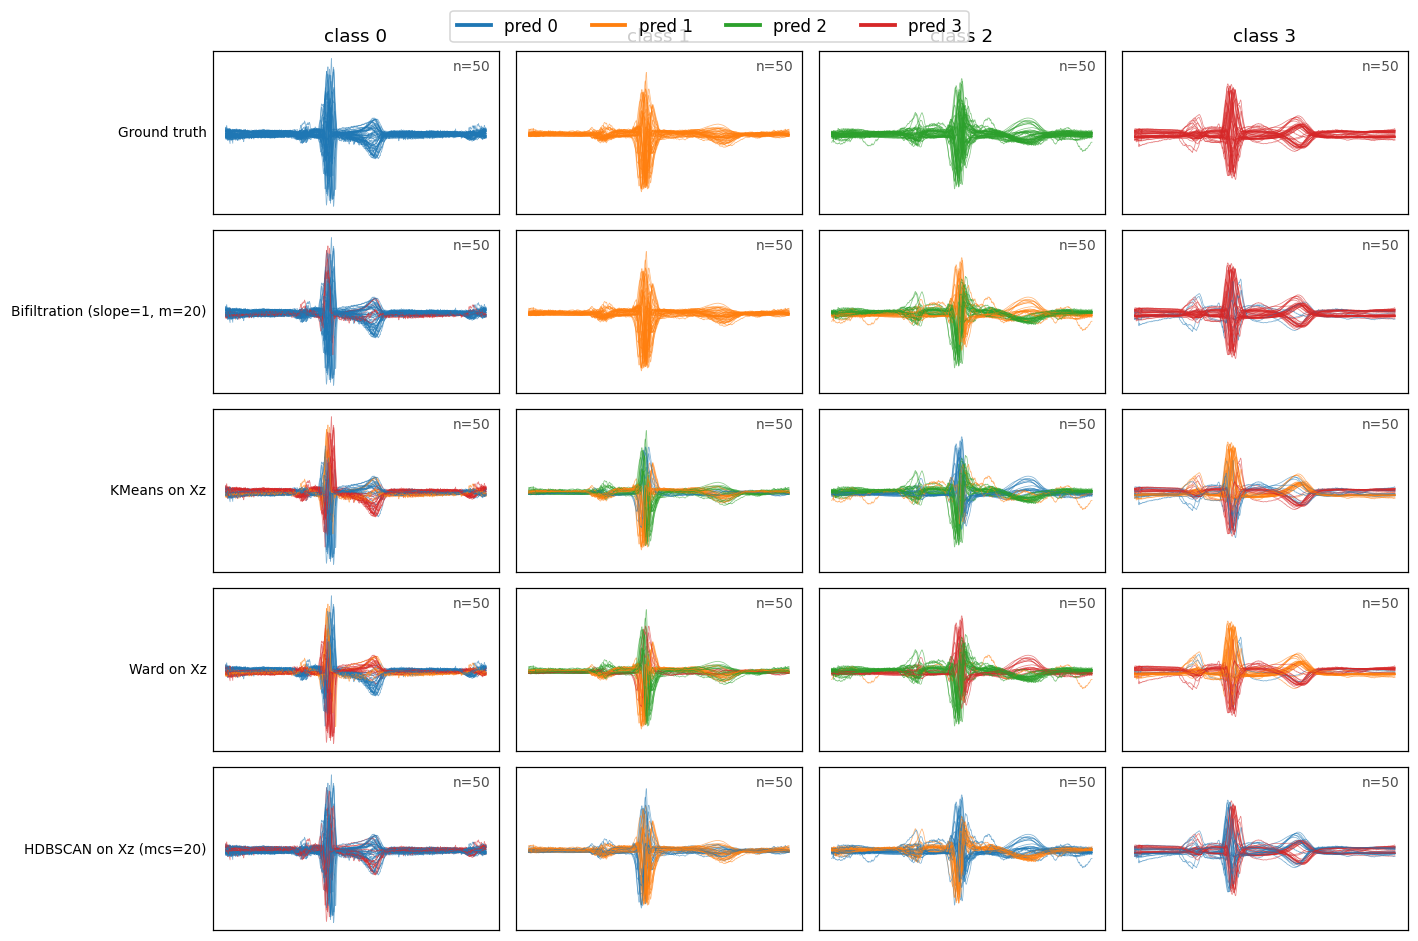

In [6]:
rows_to_show = [("Ground truth", y_true)] + [(name, labels) for name, labels in methods.items()]

fig, axes = plt.subplots(len(rows_to_show), K_TRUE,
                         figsize=(13, 1.7 * len(rows_to_show)),
                         sharex=True, sharey=True, dpi=110)
for row, (name, labels) in enumerate(rows_to_show):
    labels = np.asarray(labels)
    if name == "Ground truth":
        color_idx = labels
    else:
        a, _ = align_hungarian(labels, y_true)
        color_idx = (a - 1) % K_TRUE
    for col in range(K_TRUE):
        ax = axes[row, col]
        idxs = np.where(y_true == col)[0]
        for i in idxs:
            ax.plot(X[i], color=PRED_COLORS[color_idx[i]], lw=0.5, alpha=0.55)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.97, 0.95, f"n={len(idxs)}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="0.3")
        if row == 0: ax.set_title(f"class {col}", fontsize=12)
        if col == 0: ax.set_ylabel(name, fontsize=9, rotation=0, ha="right", va="center")

handles = [plt.Line2D([0], [0], color=PRED_COLORS[c], lw=2.5, label=f"pred {c}")
           for c in range(K_TRUE)]
fig.legend(handles=handles, loc="upper center", ncol=K_TRUE,
           bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.tight_layout(); plt.show()